###                     Machea Learing project 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:

# Load dataset
df = pd.read_csv("Heart.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:

# Check for missing values
print(df.isnull().sum())  # Show the number of missing values in each column


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [8]:
# Define X (features) and y (target)
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

In [9]:
# Encode categorical features (if any categorical data remains)
label_encoders = {}
for column in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders[column] = le

# Scale all numerical features
scaler = StandardScaler()
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns
X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

In [10]:
# Split the dataset (75% train, 25% test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.75, random_state=42, stratify=y)

# Further split into validation (20%) and test (80%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, train_size=0.2, test_size=0.8, random_state=42, stratify=y_temp
)


In [11]:
import numpy as np
import pandas as pd


In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


In [13]:
def cost_function(X, y, theta):
    m = len(y)
    predictions = sigmoid(np.dot(X, theta))
    cost = (-y * np.log(predictions) - (1 - y) * np.log(1 - predictions)).mean()
    return cost


In [14]:
def gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    for _ in range(iterations):
        predictions = sigmoid(np.dot(X, theta))
        gradients = np.dot(X.T, (predictions - y)) / m
        theta -= learning_rate * gradients
    return theta


In [15]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.theta = None

    def fit(self, X, y):
        # Add a bias column (ones) to the input features matrix
        X = np.hstack([np.ones((X.shape[0], 1)), X])  # Add bias term (intercept)
        # Initialize theta (weights) to zeros
        self.theta = np.zeros(X.shape[1])
        
        # Gradient Descent to optimize theta
        self.theta = gradient_descent(X, y, self.theta, self.learning_rate, self.iterations)
    
    def predict(self, X):
        # Add a bias column (ones) to the input features matrix for prediction
        X = np.hstack([np.ones((X.shape[0], 1)), X])  # Add bias term (intercept)
        predictions = sigmoid(np.dot(X, self.theta))
        return [1 if p >= 0.5 else 0 for p in predictions]


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix


In [19]:

# Initialize and train the logistic regression model
model = LogisticRegressionScratch(learning_rate=0.01, iterations=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)



In [20]:
# Evaluate the model
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Calculate Precision, Recall, and F1 Score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print Precision, Recall, and F1-Score
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)


Accuracy: 85.33%
Precision: 0.86
Recall: 0.87
F1 Score: 0.87
Confusion Matrix:
[[68 14]
 [13 89]]


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve

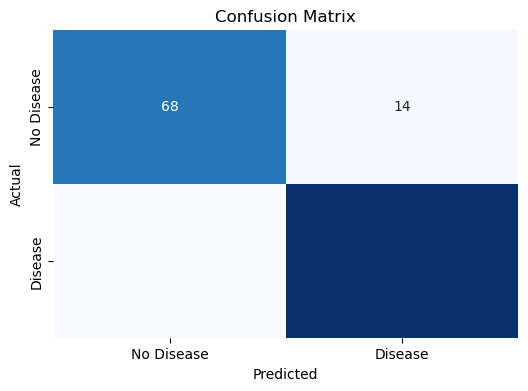

In [30]:

# Visualization 1: Confusion Matrix Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


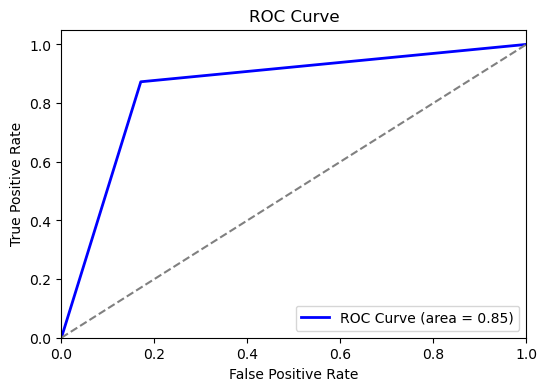

In [31]:

# Visualization 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='b', lw=2, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()


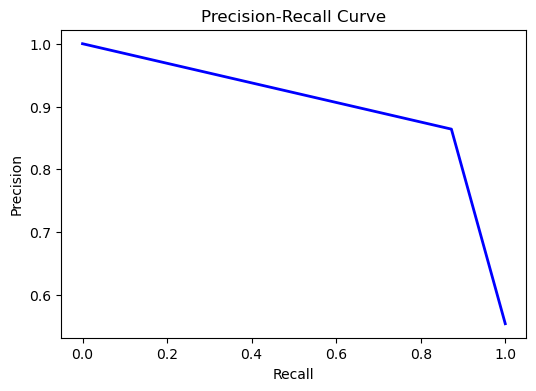

In [32]:

# Visualization 3: Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred)

plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

In [35]:
pip install joblib


Note: you may need to restart the kernel to use updated packages.


In [38]:
import joblib

In [42]:
# Save the trained model
joblib.dump(model, 'logistic_regression_model.pkl')


['logistic_regression_model.pkl']

In [41]:

joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

print("logistic_regression_model, scaler, and label encoders saved.")

Model, scaler, and label encoders saved.
